## Galassia - Esercitazione

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.optimize import least_squares
from astropy.table import Table

In [49]:
gaia = Table.read('Gaia.vot.gz')

In [82]:
# Posizione(l, b)
l = gaia['l']
b = gaia['b']

# Parallasse
parallax = gaia['parallax']
parallax_err = gaia['parallax_error']

# Velocità Radiale
rv = gaia['radial_velocity']
rv_err = gaia['radial_velocity_error']

# Moto Proprio
pmra = gaia['pmra']
pmdec = gaia['pmdec']

# Considerare solo stelle vicine al piano galattico
mask = (
    (parallax > 0) &
    (parallax_err / parallax < 0.2) &
    (~np.isnan(rv))
)

data = gaia[mask]
# distance is not in parsecs, but in milliarcseconds
distance = 1000 / data['parallax']
data['distance'] = distance

print("Number of analysed stars: ", len(gaia))

Number of analysed stars:  349153


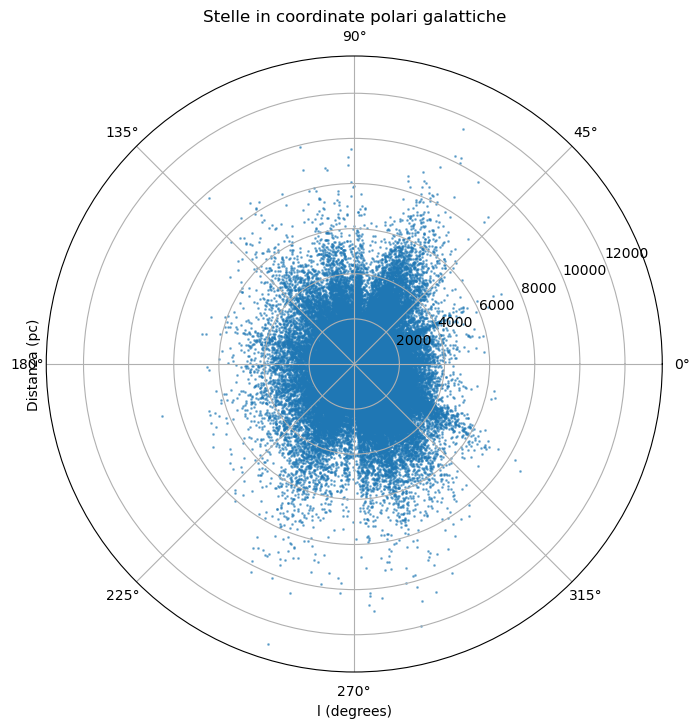

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')
ax.scatter(np.radians(data['l']), data['distance'], s=1, alpha=0.5)
ax.set_xlabel('l (degrees)')
ax.set_ylabel('Distanza (pc)')
ax.set_title('Stelle in coordinate polari galattiche')
plt.show()

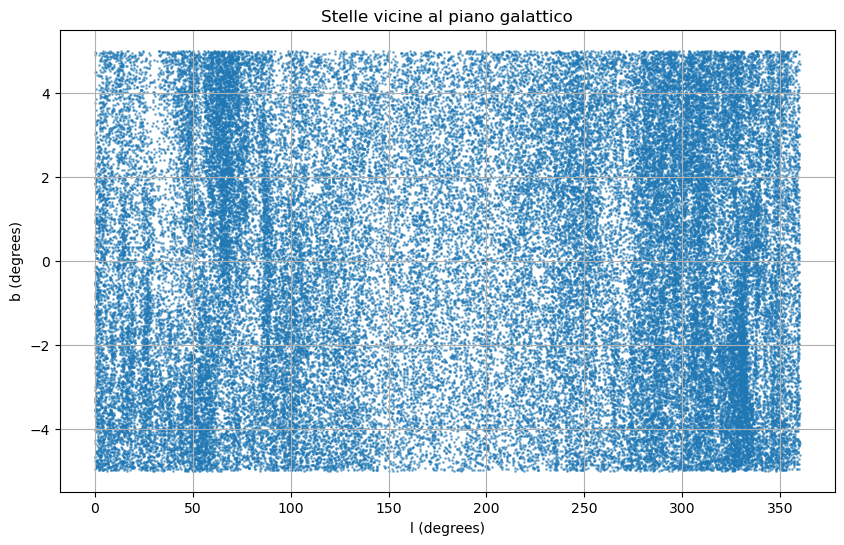

In [5]:
# plot data
plt.figure(figsize=(10, 6))
plt.scatter(data['l'], data['b'], s=1, alpha=0.5)
plt.xlabel('l (degrees)')
plt.ylabel('b (degrees)')
plt.title('Stelle vicine al piano galattico')
plt.grid()
plt.show()

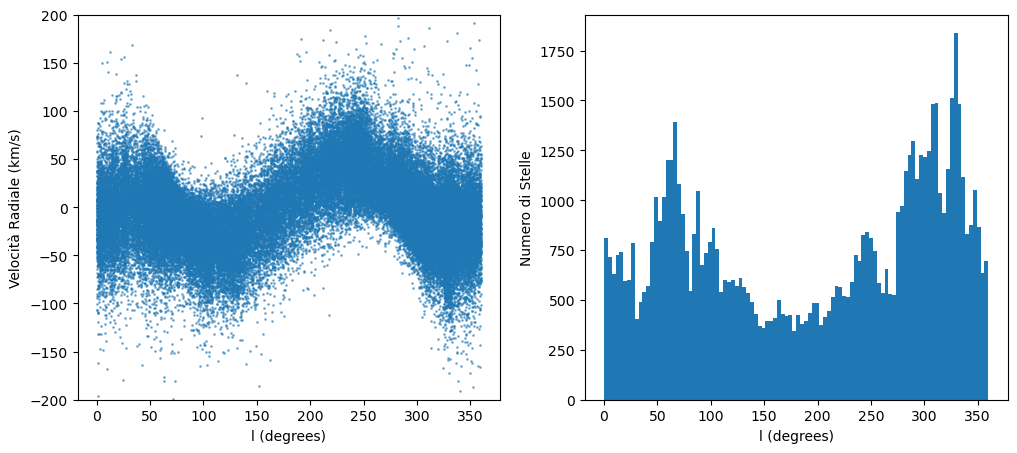

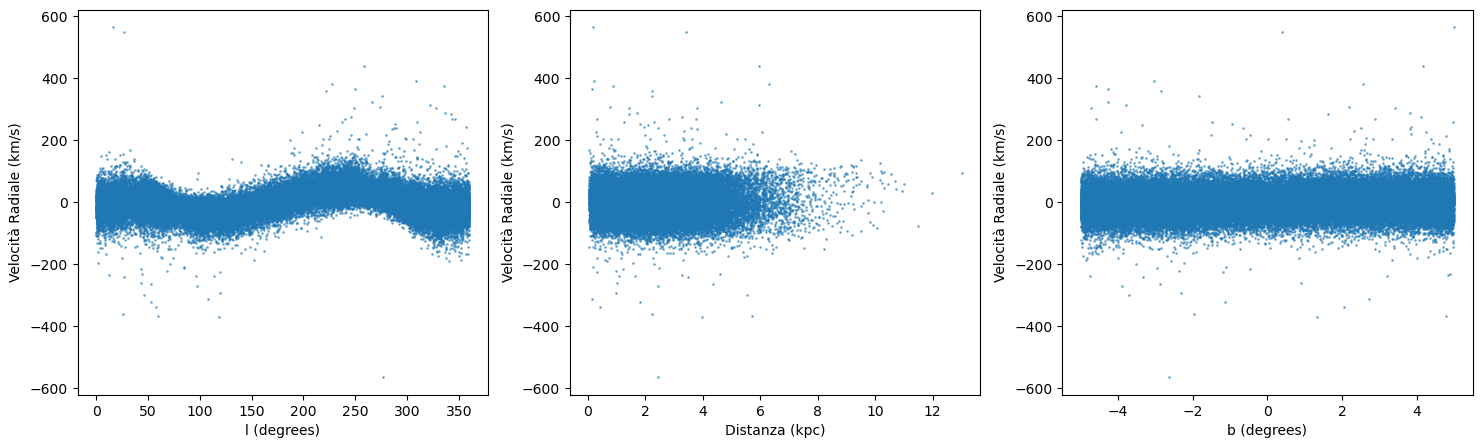

In [51]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
axes[0].scatter(data['l'], data['radial_velocity'], s=1, alpha=0.5, )
axes[0].set_xlabel('l (degrees)')
axes[0].set_ylabel('Velocità Radiale (km/s)')
axes[0].set_ylim(-200, 200)
axes[1].hist(data['l'], bins=100)
axes[1].set_xlabel('l (degrees)')
axes[1].set_ylabel('Numero di Stelle')


plt.show()

fig, axes = plt.subplots(ncols=3, figsize=(18, 5))
axes[0].scatter(data['l'], data['radial_velocity'], s=1, alpha=0.5)
axes[0].set_xlabel('l (degrees)')
axes[0].set_ylabel('Velocità Radiale (km/s)')
#axes[0].set_ylim(0, 200)
axes[1].scatter(1/data['parallax'], data['radial_velocity'],s=1, alpha=0.5, )
axes[1].set_ylabel('Velocità Radiale (km/s)')
axes[1].set_xlabel('Distanza (kpc)')

axes[2].scatter(data['b'], data['radial_velocity'], s=1, alpha=0.5)
axes[2].set_xlabel('b (degrees)')
axes[2].set_ylabel('Velocità Radiale (km/s)')

plt.show()

In [83]:
data = np.random.choice(data, size=10000, replace=False)
print("Number of analysed stars: ", len(data))

Number of analysed stars:  10000


In [84]:
# likelihood

R_sun = 8200  # kpc

def R_star(d, l):
    return np.sqrt(d**2 + R_sun**2 - 2 * d * R_sun * np.cos(np.radians(l)))

def fun_model(V_rot, l, b, d, U_sun, V_sun, W_sun):
    return V_rot * (R_sun/R_star(d, l) - 1) * np.sin(np.radians(l)) - U_sun * np.cos(np.radians(l)) * np.cos(np.radians(b)) - V_sun * np.sin(np.radians(l))*np.cos(np.radians(b)) - W_sun *np.sin(np.radians(b))

def log_likelihood(theta, l, b, d, rv, rv_err):
    V_rot, U_sun, V_sun, W_sun = theta
    model = fun_model(V_rot, l,b, d, U_sun, V_sun, W_sun)
    # expect gaussian distribution for the measurements
    sigma2 = rv_err ** 2
    return -0.5 * np.sum((rv - model) ** 2 / sigma2 + np.log(2*np.pi*sigma2))

# uninformative priors using uniform distributions
def log_prior(theta):
    V_rot, U_sun, V_sun, W_sun = theta
    if 0 < V_rot < 300 and -30 < U_sun < 30 and -30 < V_sun < 30 and -30 < W_sun < 30: # add U_sun and V_sun priors
        return 0.0
    else:
        return -np.inf

def log_probability(theta, l, b, d, rv, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, l, b, d, rv, rv_err)

Qui ci conviene non partire dai minimi quadrati

In [85]:
nwalkers = 32
ndim = 4

initial = np.array([np.random.uniform(0,300,nwalkers),np.random.uniform(-30.,30.,nwalkers),np.random.uniform(-30.,30.,nwalkers),np.random.uniform(-30.,30.,nwalkers)]).T
print(initial.shape)

(32, 4)


In [86]:
sampler = emcee.EnsembleSampler(
    nwalkers, 
    ndim,
    log_probability,
    args=(
        np.asarray(data['l']), 
        np.asarray(data['b']), 
        np.asarray(data['distance']), 
        np.asarray(data['radial_velocity']), 
        np.asarray(data['radial_velocity_error'])
    )
)
sampler.run_mcmc(initial, 3500, progress=True)

100%|██████████| 3500/3500 [02:05<00:00, 27.83it/s]


State([[181.94743087  11.85732062  25.3368261    6.94096395]
 [181.95025304  11.85191383  25.33454874   6.94782387]
 [181.91525724  11.85210255  25.32849767   6.94210111]
 [182.01624324  11.8467862   25.331581     6.95556899]
 [181.97931568  11.84843989  25.33667157   6.97512667]
 [182.02263282  11.85598715  25.34275459   6.93777893]
 [182.06637254  11.85112216  25.33020437   6.95933658]
 [182.04544659  11.83982295  25.340339     6.95667552]
 [181.89869069  11.84335873  25.34286041   6.95231689]
 [181.97464843  11.82648627  25.3346687    6.95319332]
 [181.95226167  11.86126502  25.33312711   6.93408881]
 [182.06510576  11.84481334  25.33272138   6.95235155]
 [181.99173929  11.84325664  25.33815741   6.96559267]
 [182.02479638  11.85641941  25.33867717   6.94538722]
 [181.99455992  11.84732575  25.33796998   6.94275727]
 [181.88369661  11.83647187  25.32726752   6.93683904]
 [182.01186034  11.8512418   25.34066328   6.94654684]
 [181.96801115  11.85429775  25.33026514   6.94751925]
 [18

In [87]:
samples = sampler.get_chain()
print(f"MCMC shape: {samples.shape}")  # (steps, walkers, ndim)

MCMC shape: (3500, 32, 4)


Text(0.5, 0, 'step number')

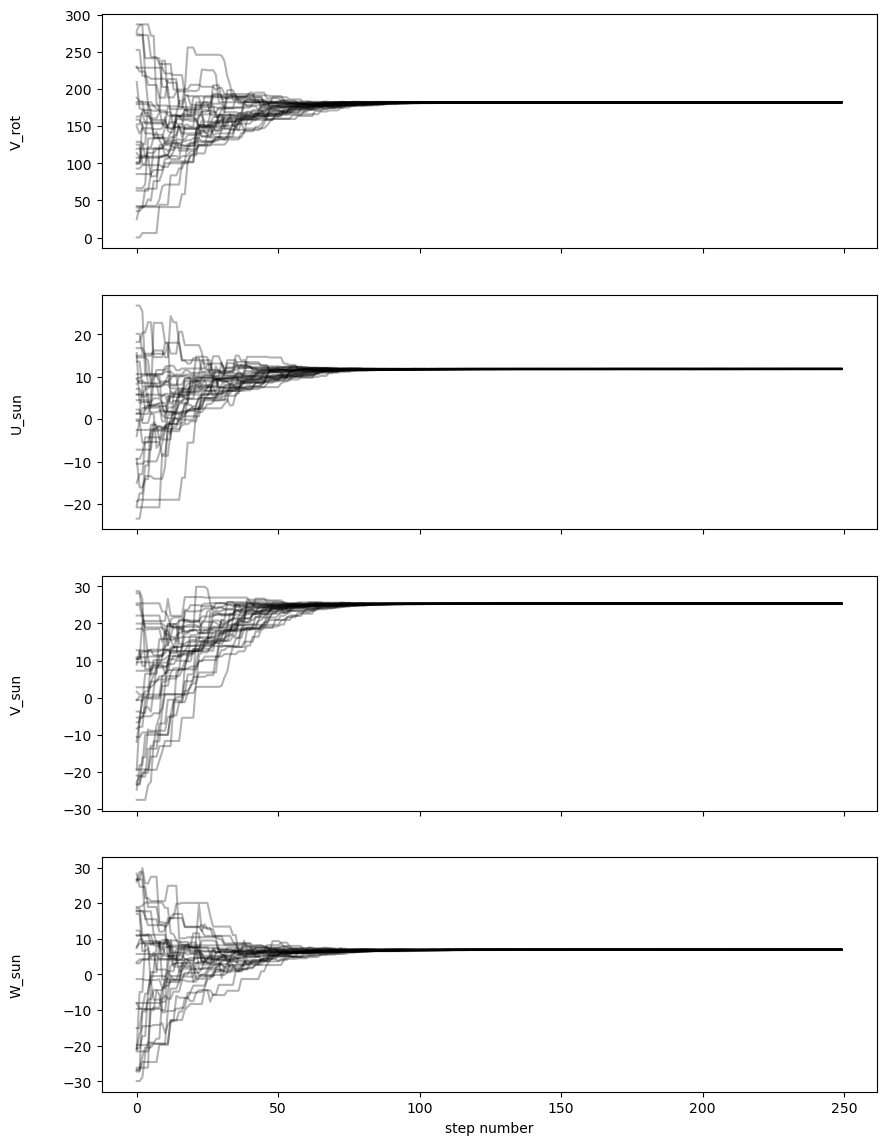

In [92]:
fig, axes = plt.subplots(4, figsize=(10, 14), sharex=True)
labels = ["V_rot", "U_sun", "V_sun", "W_sun"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i][:250], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

Autocorrelation time: 30.58
Flattened samples shape: (7232, 4)


Text(0.5, 0, 'step number')

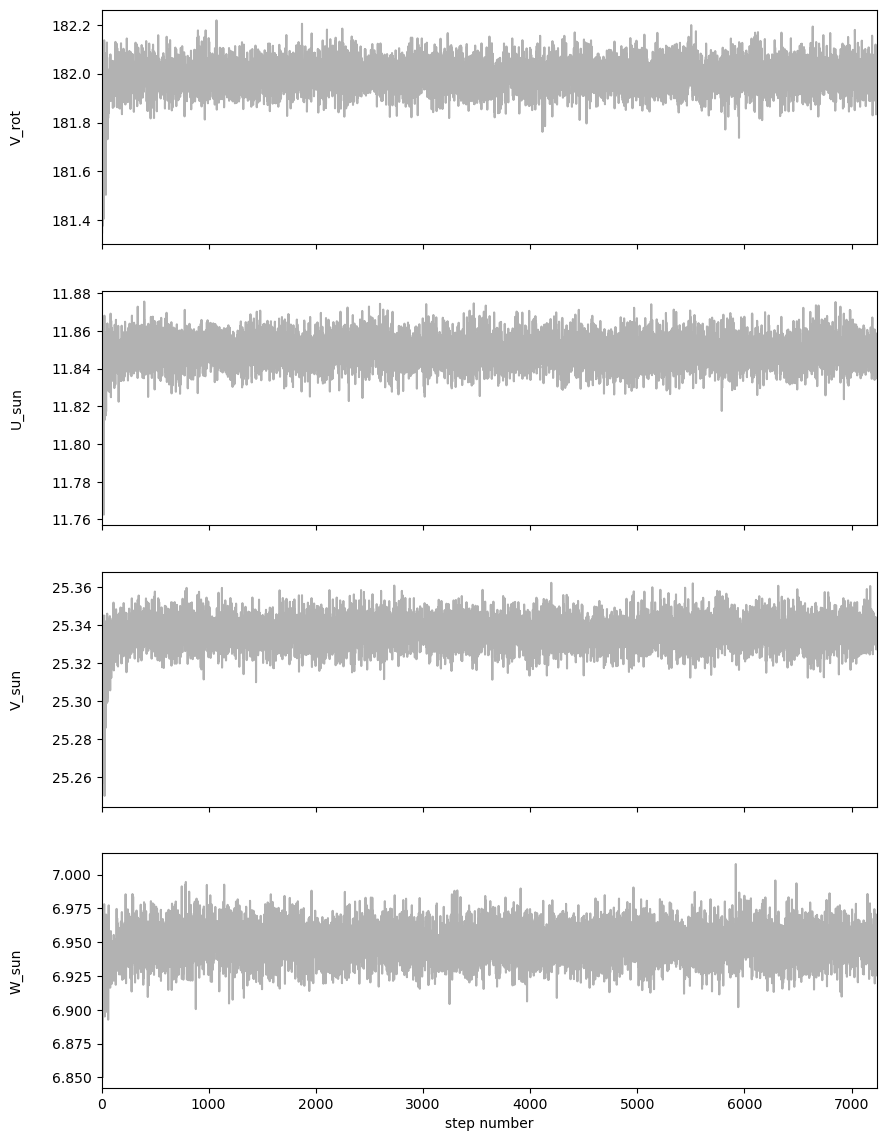

In [93]:
# Check autocorrelation time and convergence
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time: {tau[0]:.2f}")

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(f"Flattened samples shape: {flat_samples.shape}")

# plot flat samples
fig, axes = plt.subplots(4, figsize=(10, 14), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number")

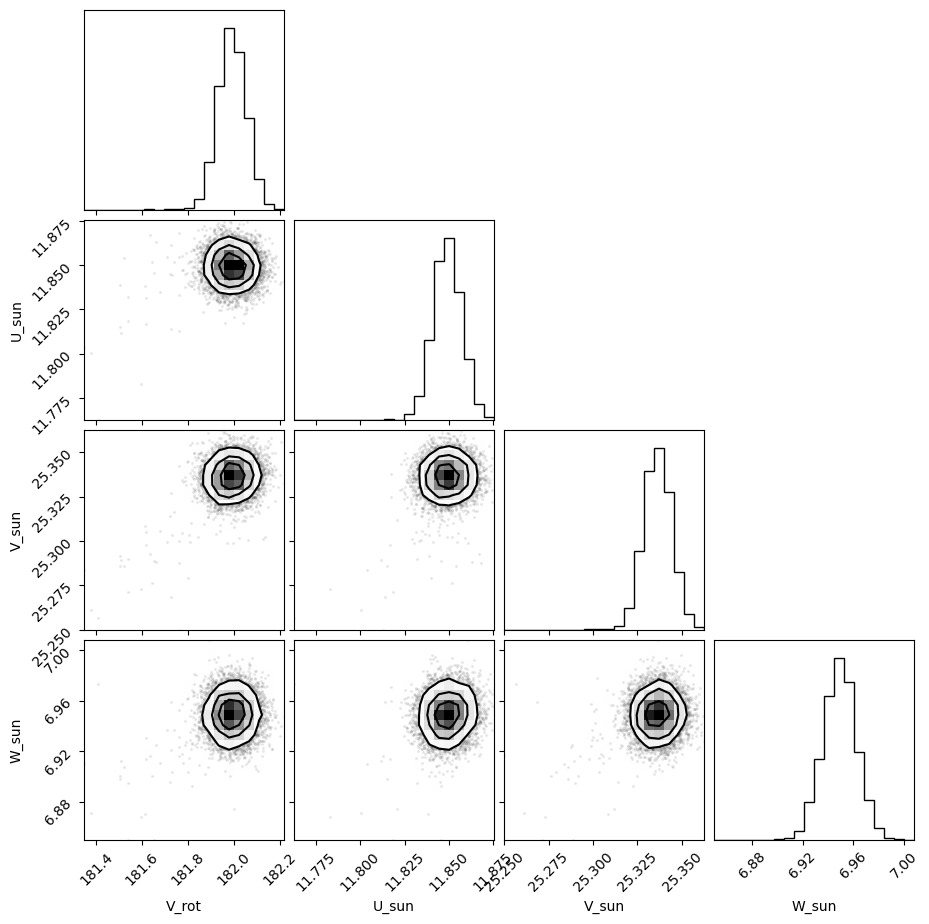

In [94]:
import corner 

fig = corner.corner(
    flat_samples, labels=labels
)
plt.show()

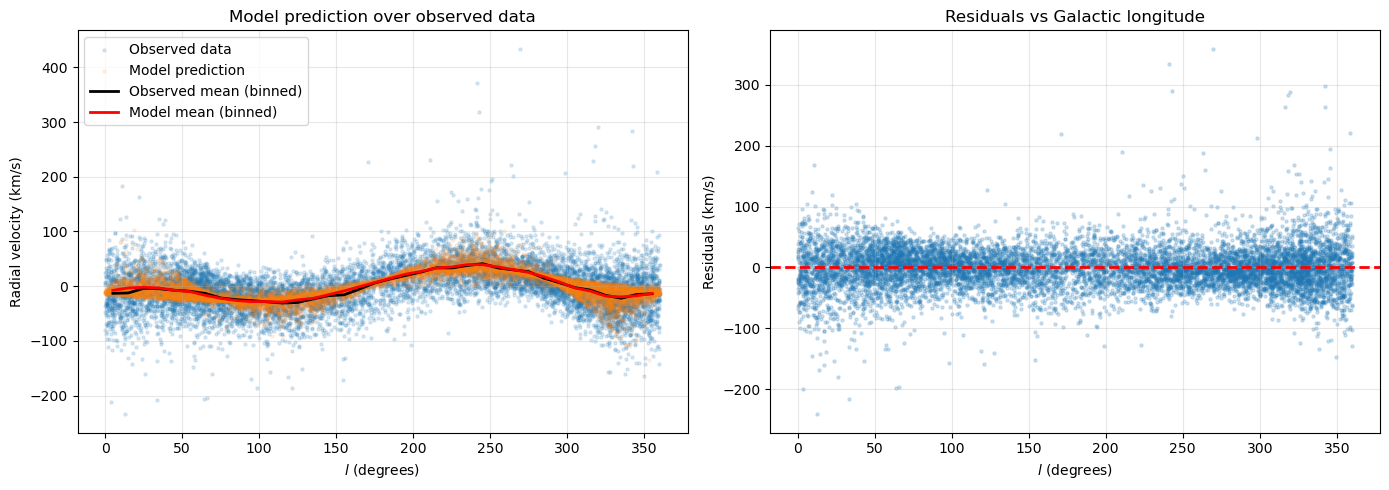

In [100]:
# Use posterior median parameters when available; otherwise fallback to least-squares
theta_hat = np.median(flat_samples, axis=0)
V_rot_hat, U_sun_hat, V_sun_hat, W_sun_hat = theta_hat

# Predict radial velocity for each star using its own distance
l_obs = np.asarray(data['l'].data)
d_obs = np.asarray(data['distance'].data)
b_obs = np.asarray(data['b'].data)
rv_obs = np.asarray(data['radial_velocity'].data)
rv_pred = fun_model(V_rot_hat, l_obs, b_obs, d_obs, U_sun_hat, V_sun_hat, W_sun=W_sun_hat)
#fun_model(V_rot, l, b, d, U_sun, V_sun, W_sun):

# Build binned trends vs Galactic longitude for a clearer overlay
bins = np.linspace(0, 360, 37)  # 10-degree bins
centers = 0.5 * (bins[:-1] + bins[1:])
obs_binned = np.full(len(centers), np.nan)
pred_binned = np.full(len(centers), np.nan)

for i in range(len(centers)):
    in_bin = (l_obs >= bins[i]) & (l_obs < bins[i + 1])
    if np.any(in_bin):
        obs_binned[i] = np.mean(rv_obs[in_bin])
        pred_binned[i] = np.mean(rv_pred[in_bin])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Data + model overlay
ax = axes[0]
ax.scatter(l_obs, rv_obs, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, rv_pred, s=5, alpha=0.10, label='Model prediction')
ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Radial velocity (km/s)')
ax.set_title('Model prediction over observed data')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[1]
residuals = rv_obs - rv_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()